## Ejercicios Prácticos: Componentes Fundamentales de un Agente

### 🎯 Plan de Lección: Bloques de Construcción de Agentes Inteligentes

Esta lección ofrece ejercicios prácticos que desglosan cada componente fundamental de un agente de IA, ayudando a los estudiantes a comprender cómo la percepción, el razonamiento, la acción, la memoria y la planificación trabajan en conjunto dentro del bucle de acción/reflexión.
Requisitos previos: Configuración avanzada

### Bibliotecas Principales Utilizadas
- OpenAI: Proporciona el cliente de la API para el análisis y la comprensión de texto impulsados por LLM
- json: Maneja el análisis y la validación de las respuestas estructuradas del LLM
- dataclasses: Crea contenedores de datos estructurados para la gestión de la memoria y el estado del agente
- os: Gestiona las variables de entorno para el manejo seguro de la clave de API

In [ ]:
# agent_components_setup.py
import os
import json
from datetime import datetime
from typing import Dict, List, Any
from dataclasses import dataclass
from openai import OpenAI
from dotenv import load_dotenv

load_dotenv()

client = OpenAI(
    api_key=os.getenv("OPENAI_API_KEY"),
)

@dataclass
class AgentMemory:
    short_term: List[Dict]
    long_term: Dict[str, Any]
    episodic: List[Dict]

@dataclass
class AgentState:
    current_goal: str
    beliefs: Dict[str, Any]
    intentions: List[str]

## Ejercicio 1: Componente de Percepción

### Concepto: La percepción consiste en tomar la entrada cruda del entorno y convertirla en una comprensión estructurada.

### Lógica del Código y Flujo: Visión General de Alto Nivel
El módulo de percepción actúa como el sistema de comprensión de primera línea de un agente de IA. Toma la entrada cruda del usuario y la transforma en datos estructurados y accionables que otros componentes del agente pueden procesar. El flujo de trabajo comienza con un análisis impulsado por LLM, utilizando prompts cuidadosamente diseñados para extraer el significado semántico, con un sólido mecanismo de reserva basado en reglas en caso de que el método principal falle. El sistema valida todas las salidas para garantizar la calidad de los datos antes de pasar las percepciones estructuradas a los componentes posteriores.

### Diagrama de Flujo Visual
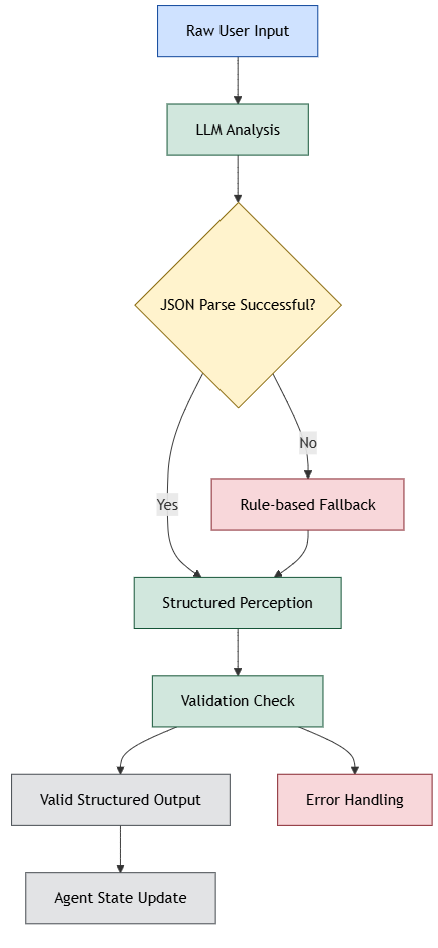

## Desglose del Código Paso a Paso

### Estructuras Centrales del Agente
- Data Class AgentMemory: Define una arquitectura de memoria de tres niveles con ranuras de memoria a corto plazo, a largo plazo y episódica
- Data Class AgentState: Rastrea el estado operativo actual del agente, incluyendo los objetivos activos, los sistemas de creencias y las colas de intenciones

### Inicialización del Módulo de Percepción
- Configura las categorías de intención soportadas que cubren los tipos de interacción comunes
- Prepara el sistema tanto para las vías de análisis impulsadas por IA como para las basadas en reglas

### Procesamiento Principal de la Entrada
- Análisis Impulsado por LLM: Usa prompts de sistema detallados para guiar al modelo de lenguaje en la extracción de cinco dimensiones clave de la entrada del usuario
- Integración del Contexto: Incorpora el contexto de la conversación previa para mantener la coherencia a lo largo de las interacciones
- Formato de Salida Estructurado: Impone un formato de respuesta JSON para un manejo consistente de los datos

### Sistema de Análisis de Reserva
- Detección de Intención: Implementa coincidencia de palabras clave para una clasificación básica de la intención cuando el LLM falla
- Extracción de Entidades: Usa patrones de mayúsculas y numéricos para identificar entidades potenciales
- Puntuación de Confianza: Asigna puntuaciones de confianza más bajas a los resultados de reserva para que los componentes posteriores estén al tanto

### Aseguramiento de la Calidad
- Comprobaciones de Validación: Garantiza que todos los campos de datos requeridos estén presentes en la salida de la percepción
- Manejo de Errores: Proporciona una degradación elegante cuando los métodos de análisis principales encuentran problemas

### Conexión con la Lección
- Comprensión del Lenguaje Natural: Demuestra la implementación práctica de convertir texto no estructurado en representaciones semánticas estructuradas
- Diseño Robusto de Sistemas: Muestra la importancia de los mecanismos de reserva cuando los componentes principales de IA fallan, abordando las preocupaciones sobre la propagación de errores
- Arquitectura Modular: Ilustra cómo los componentes de percepción encajan en sistemas de agentes más grandes, apoyando la separación de responsabilidades
- Gestión del Contexto: Resalta cómo mantener el historial de conversación mejora la precisión de la comprensión
- Puntuación de Confianza: Se relaciona con los enfoques probabilísticos del reconocimiento de voz, donde los sistemas cuantifican su certeza
- Clasificación de Intención: Conecta con los conceptos teóricos de la clasificación de actos de diálogo en sistemas de IA conversacional
- Procesamiento Multimodal: Aunque se centra en el texto, la arquitectura admite la extensión a entradas de voz mediante un preprocesamiento de reconocimiento automático del habla (ASR)

In [ ]:
# perception_component.py
class PerceptionModule:
    """
    Handles input processing: text understanding, intent classification, and context extraction.
    """

    def __init__(self):
        self.supported_intents = [
            "greeting", "question", "request", "complaint", "feedback", "goodbye"
        ]

    def parse_input(self, raw_input: str, context: Dict = None) -> Dict[str, Any]:
        """Convert raw input into structured understanding"""

        system_prompt = """
        You are a perception module for an AI agent. Analyze the user's input and extract:
        1. Primary intent (greeting, question, request, complaint, feedback, goodbye)
        2. Key entities mentioned (people, places, things, numbers)
        3. Emotional tone (positive, negative, neutral, urgent)
        4. Actionable requests
        5. Contextual references

        Return JSON format:
        {
            "intent": "primary_intent",
            "entities": ["entity1", "entity2"],
            "tone": "emotional_tone",
            "actions_requested": ["action1", "action2"],
            "context_links": ["reference1", "reference2"],
            "confidence": 0.95
        }
        """

        context_info = f"Previous context: {context}" if context else "No previous context"

        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": f"Input: {raw_input}\n{context_info}"}
            ],
            temperature=0.1
        )

        try:
            perception = json.loads(response.choices[0].message.content)
            return perception
        except json.JSONDecodeError:
            # Fallback parsing
            return self.fallback_parse(raw_input)

    def fallback_parse(self, raw_input: str) -> Dict[str, Any]:
        """Rule-based fallback when LLM parsing fails"""
        input_lower = raw_input.lower()

        # Simple intent detection
        if any(word in input_lower for word in ["hello", "hi", "hey"]):
            intent = "greeting"
        elif "?" in raw_input:
            intent = "question"
        elif any(word in input_lower for word in ["please", "can you", "I need"]):
            intent = "request"
        elif any(word in input_lower for word in ["problem", "issue", "complaint"]):
            intent = "complaint"
        elif any(word in input_lower for word in ["bye", "goodbye", "see you"]):
            intent = "goodbye"
        else:
            intent = "statement"

        # Simple entity extraction
        entities = []
        for word in raw_input.split():
            if word.istitle() and len(word) > 2:  # Simple proper noun detection
                entities.append(word)
            elif word.isdigit():  # Numbers
                entities.append(word)

        return {
            "intent": intent,
            "entities": entities,
            "tone": "neutral",
            "actions_requested": [],
            "context_links": [],
            "confidence": 0.7
        }

    def validate_perception(self, perception: Dict) -> bool:
        """Validate that perception output meets requirements"""
        required_fields = ["intent", "entities", "tone", "actions_requested"]
        return all(field in perception for field in required_fields)

# Demonstrate perception component
def demo_perception():
    print("=== Perception Component Demo ===")
    perceiver = PerceptionModule()

    test_inputs = [
        "Hello, I'm having trouble with my order #1234 from last week",
        "What's the status of my refund for the damaged product?",
        "I need to update my shipping address for future orders",
        "This is urgent! My package was supposed to arrive yesterday"
    ]

    for i, user_input in enumerate(test_inputs, 1):
        print(f"\n{i}. Input: {user_input}")
        perception = perceiver.parse_input(user_input)
        print(f"   Intent: {perception['intent']}")
        print(f"   Entities: {perception['entities']}")
        print(f"   Tone: {perception['tone']}")
        print(f"   Actions: {perception['actions_requested']}")

demo_perception()

=== Perception Component Demo ===

1. Input: Hello, I'm having trouble with my order #1234 from last week
   Intent: complaint
   Entities: ['order #1234', 'last week']
   Tone: negative
   Actions: ['troubleshoot order issue']

2. Input: What's the status of my refund for the damaged product?
   Intent: question
   Entities: ['refund', 'damaged product']
   Tone: neutral
   Actions: ['check refund status']

3. Input: I need to update my shipping address for future orders
   Intent: request
   Entities: ['shipping address', 'future orders']
   Tone: neutral
   Actions: ['update shipping address']

4. Input: This is urgent! My package was supposed to arrive yesterday
   Intent: greeting
   Entities: ['This']
   Tone: neutral
   Actions: []


## Aprendizaje Clave: La percepción transforma la entrada cruda en datos estructurados que otros componentes pueden usar.

### Ejercicio 2: Componentes de Memoria

### Concepto: Los agentes necesitan diferentes tipos de memoria: a corto plazo (conversación), a largo plazo (conocimiento) y episódica (experiencias).

### Descripción Breve
Este código implementa un sistema integral de gestión de memoria para agentes de IA con múltiples tipos de memoria y mecanismos de recuperación. Demuestra cómo los sistemas inteligentes pueden almacenar, organizar y recordar información a través de diferentes escalas de tiempo y contextos, permitiendo el aprendizaje persistente y la conciencia contextual en la IA conversacional.

### Lógica del Código y Flujo: Visión General de Alto Nivel
El sistema de memoria organiza las experiencias del agente en cuatro tipos de memoria distintos que trabajan juntos para mantener el contexto y permitir el aprendizaje. La memoria a corto plazo maneja el historial de conversación inmediato con poda automática, la memoria a largo plazo almacena las preferencias y el conocimiento persistentes del usuario, la memoria episódica captura experiencias pasadas con perspectivas analíticas, y la memoria de trabajo gestiona el estado temporal. El sistema emplea tanto la recuperación semántica como la basada en palabras clave para encontrar memorias relevantes para las situaciones actuales.

### Diagrama de Flujo Visual
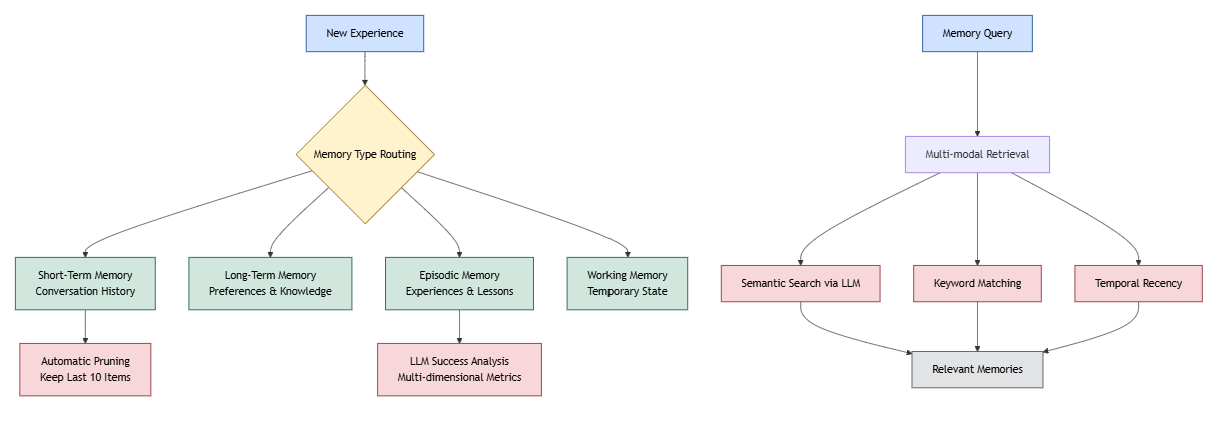

## Desglose del Código Paso a Paso

### Arquitectura del Sistema de Memoria
- Estructura de Memoria de Cuatro Niveles: Implementa almacenamiento distinto para la memoria a corto plazo (conversación), a largo plazo (conocimiento), episódica (experiencias) y de trabajo (temporal)
- Organización de Datos Estructurada: Usa diccionarios y listas con una categorización clara para un almacenamiento y recuperación eficientes

### Gestión de la Memoria a Corto Plazo
- Seguimiento del Historial de Conversación: Registra cada interacción con marcas de tiempo, roles y metadatos
- Gestión Automática del Contexto: Implementa una ventana deslizante para mantener solo los 10 intercambios más recientes
- Prevención del Desbordamiento del Contexto: Garantiza que la memoria no se sobrecargue con datos históricos

### Almacenamiento de Conocimiento a Largo Plazo
- Organización Categórica: Almacena la información en contenedores dedicados para preferencias del usuario, conocimiento del sistema y patrones aprendidos
- Mecanismo de Actualización Flexible: Permite la adición y modificación dinámica de elementos de conocimiento persistentes
- Patrones de Acceso Estructurados: Proporciona interfaces claras para almacenar y recuperar información permanente

### Aprendizaje Experiencial con la Memoria Episódica
- Registro Integral de Episodios: Captura eventos, resultados y lecciones extraídas de cada interacción
- Análisis de Métricas de Éxito: Usa la evaluación del LLM para calificar los episodios en múltiples dimensiones de rendimiento
- Cuantificación del Valor de Aprendizaje: Mide cuánto conocimiento aporta cada experiencia al desarrollo del agente

### Sistema Inteligente de Recuperación de Memoria
- Enfoque de Búsqueda Multimodal: Combina la comprensión semántica impulsada por LLM con la coincidencia de palabras clave
- Puntuación de Relevancia Consciente del Contexto: Considera el contexto de la consulta actual al buscar a través de los tipos de memoria
- Priorización Temporal: Da preferencia a las memorias recientes a la vez que mantiene el acceso a los patrones históricos

### Demostración y Prueba de la Memoria
- Flujo de Conversación Simulado: Muestra cómo el sistema de memoria acumula información a lo largo de múltiples intercambios
- Integración entre Memorias: Demuestra cómo los diferentes tipos de memoria trabajan juntos durante la recuperación
- Evaluación de Relevancia: Prueba la capacidad del sistema para encontrar memorias pertinentes a consultas específicas

### Conexión con la Lección
- Arquitecturas de Memoria en IA: Ilustra la implementación práctica de los sistemas de memoria de múltiples niveles discutidos en las teorías de arquitectura cognitiva
- Gestión de la Ventana de Contexto: Demuestra técnicas para manejar las ventanas de contexto limitadas en los modelos de lenguaje mediante la poda estratégica de la memoria
- Aprendizaje Basado en Experiencias: Conecta con los conceptos del aprendizaje por refuerzo, donde los agentes mejoran a través de experiencias acumuladas y métricas de éxito
- Teoría de la Recuperación de Información: Muestra la aplicación práctica de enfoques híbridos de búsqueda semántica y coincidencia de palabras clave
- Personalización y Adaptación: Se relaciona con cómo la memoria persistente permite que los sistemas de IA se adapten a las preferencias individuales del usuario con el tiempo
- Análisis de Errores y Aprendizaje: Demuestra cómo el análisis de los fracasos y éxitos pasados conduce a un mejor rendimiento futuro
- Contexto Temporal en el Diálogo: Resalta la importancia de mantener el historial de conversación para interacciones coherentes de múltiples turnos

In [ ]:
# memory_components.py
class MemorySystem:
    """
    Implements comprehensive memory management for AI agents.
    """

    def __init__(self):
        self.short_term_memory = []  # Current conversation
        self.long_term_memory = {   # Persistent knowledge
            "user_preferences": {},
            "system_knowledge": {},
            "learned_patterns": {}
        }
        self.episodic_memory = []   # Past experiences
        self.working_memory = {}    # Temporary state

    def add_to_short_term(self, role: str, content: str, metadata: Dict = None):
        """Add to conversation history"""
        entry = {
            "timestamp": datetime.now().isoformat(),
            "role": role,
            "content": content,
            "metadata": metadata or {}
        }
        self.short_term_memory.append(entry)

        # Keep only last 10 messages to prevent context overflow
        if len(self.short_term_memory) > 10:
            self.short_term_memory = self.short_term_memory[-10:]

    def update_long_term(self, key: str, category: str, value: Any):
        """Update long-term knowledge"""
        if category not in self.long_term_memory:
            self.long_term_memory[category] = {}
        self.long_term_memory[category][key] = value

    def record_episode(self, event: str, outcome: str, lessons: List[str]):
        """Record experiential learning"""
        episode = {
            "timestamp": datetime.now().isoformat(),
            "event": event,
            "outcome": outcome,
            "lessons": lessons,
            "success_metrics": self.calculate_success_metrics(outcome)
        }
        self.episodic_memory.append(episode)

    def calculate_success_metrics(self, outcome: str) -> Dict[str, float]:
        """Calculate success metrics based on outcome analysis"""
        system_prompt = """
        Analyze the outcome of an agent action and rate its success on several dimensions.
        Return JSON with scores from 0-1 for:
        - goal_achievement: How well the original goal was met
        - user_satisfaction: Likely user satisfaction level
        - efficiency: How efficiently the goal was achieved
        - learning_value: How much the agent learned from this episode

        Be realistic and critical in your assessment.
        """

        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": f"Outcome to analyze: {outcome}"}
            ],
            temperature=0.3
        )

        try:
            return json.loads(response.choices[0].message.content)
        except:
            return {"goal_achievement": 0.5, "user_satisfaction": 0.5, "efficiency": 0.5, "learning_value": 0.5}

    def retrieve_relevant_memory(self, query: str, memory_type: str = "all") -> Dict[str, Any]:
        """Retrieve memories relevant to current situation"""

        system_prompt = """
        You are a memory retrieval system. Based on the current query and context,
        identify which past memories might be relevant. Consider:
        - Similar situations
        - User preferences
        - Past successes/failures
        - Learned patterns

        Return JSON with relevant memories by category.
        """

        context = f"""
        Current query: {query}
        Available memories:
        - Short-term: {len(self.short_term_memory)} recent exchanges
        - Long-term: {len(self.long_term_memory)} knowledge items
        - Episodic: {len(self.episodic_memory)} past experiences
        """

        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": context}
            ],
            temperature=0.1
        )

        # This would be more sophisticated in a real system
        relevant_memories = {
            "short_term": self.short_term_memory[-3:] if self.short_term_memory else [],
            "long_term": self.get_relevant_long_term(query),
            "episodic": self.get_relevant_episodes(query)
        }

        return relevant_memories

    def get_relevant_long_term(self, query: str) -> Dict[str, Any]:
        """Extract relevant long-term memories"""
        relevant = {}
        query_lower = query.lower()

        for category, items in self.long_term_memory.items():
            for key, value in items.items():
                if key.lower() in query_lower or any(word in query_lower for word in str(value).lower().split()[:5]):
                    if category not in relevant:
                        relevant[category] = {}
                    relevant[category][key] = value

        return relevant

    def get_relevant_episodes(self, query: str) -> List[Dict]:
        """Find relevant past experiences"""
        relevant = []
        query_lower = query.lower()

        for episode in self.episodic_memory[-10:]:  # Check recent episodes
            episode_text = f"{episode['event']} {episode['outcome']} {''.join(episode['lessons'])}".lower()
            if any(word in episode_text for word in query_lower.split()):
                relevant.append(episode)

        return relevant

# Demonstrate memory system
def demo_memory_system():
    print("\n=== Memory System Demo ===")
    memory = MemorySystem()

    # Simulate a conversation
    conversations = [
        ("user", "I prefer email notifications instead of text messages"),
        ("assistant", "I've noted your preference for email notifications"),
        ("user", "My order #5678 hasn't arrived yet"),
        ("assistant", "Let me check the status of order #5678"),
        ("user", "Can you update my contact preference to phone calls instead?"),
    ]

    for role, content in conversations:
        memory.add_to_short_term(role, content)

    # Add long-term knowledge
    memory.update_long_term("notification_preference", "user_preferences", "email")
    memory.update_long_term("contact_method", "user_preferences", "phone")

    # Record an episode
    memory.record_episode(
        "Handled shipping delay complaint",
        "User satisfied with resolution",
        ["Users appreciate proactive shipping updates", "Offer alternatives when delays occur"]
    )

    # Test memory retrieval
    test_query = "I have a shipping problem with my order"
    relevant_memories = memory.retrieve_relevant_memory(test_query)

    print(f"Query: {test_query}")
    print(f"Relevant short-term memories: {len(relevant_memories['short_term'])}")
    print(f"Relevant long-term memories: {relevant_memories['long_term']}")
    print(f"Relevant episodes: {len(relevant_memories['episodic'])}")

demo_memory_system()


=== Memory System Demo ===
Query: I have a shipping problem with my order
Relevant short-term memories: 3
Relevant long-term memories: {}
Relevant episodes: 1


## Aprendizaje Clave: Los diferentes tipos de memoria cumplen diferentes propósitos en la cognición del agente.

### Ejercicio 3: Componente de Razonamiento

### Concepto: El razonamiento consiste en usar la percepción y la memoria para tomar decisiones y formar planes.

### Descripción Breve
Este código implementa un sofisticado motor de razonamiento que procesa percepciones, integra la memoria y genera decisiones estratégicas para agentes de IA. Demuestra cómo los sistemas inteligentes pueden analizar situaciones, actualizar creencias, seleccionar estrategias de respuesta y planificar acciones, todo ello manteniendo rastros de razonamiento transparentes.

### Lógica del Código y Flujo: Visión General de Alto Nivel
El motor de razonamiento actúa como el sistema central de toma de decisiones que une la percepción y la acción. Toma las percepciones estructuradas del sistema de entrada, recupera memorias relevantes, actualiza las creencias actuales del agente sobre el mundo, selecciona estrategias de respuesta apropiadas, genera rastros de razonamiento transparentes, calcula niveles de confianza y planifica acciones específicas. El sistema usa una combinación de cálculos basados en reglas y análisis impulsado por LLM para tomar decisiones informadas.

### Diagrama de Flujo Visual
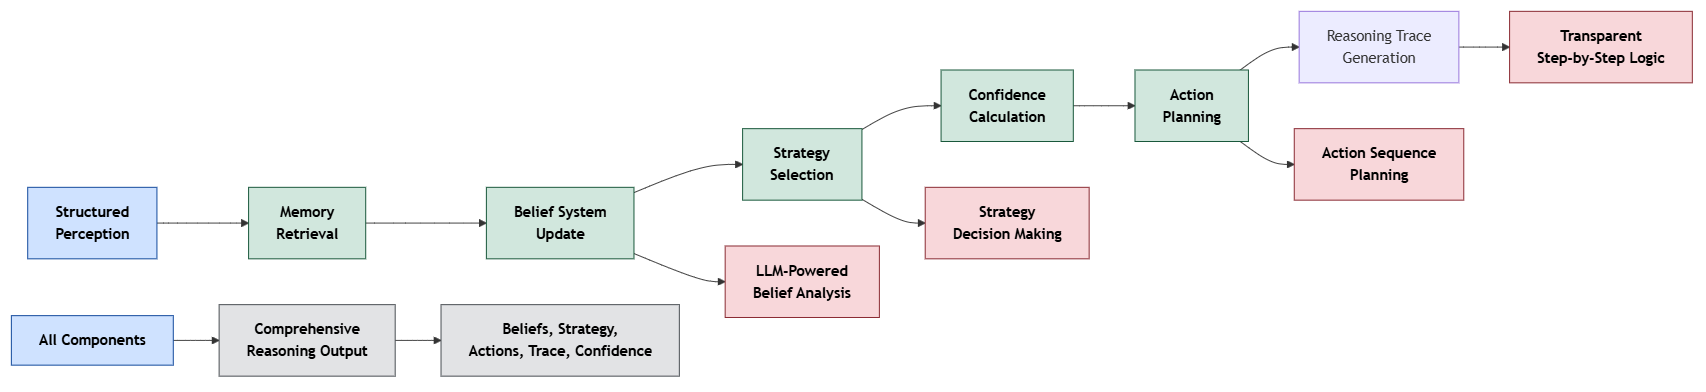

## Desglose del Código Paso a Paso
### Inicialización del Motor de Razonamiento
- Integración del Sistema de Memoria: Se conecta al sistema de memoria externo para la recuperación de información contextual
- Gestión del Estado: Inicializa las creencias actuales y los objetivos activos para mantener el estado del agente a lo largo de las interacciones

### Pipeline Principal de Procesamiento de Situaciones
- Integración de la Memoria: Recupera contexto histórico relevante basándose en los elementos de la percepción actual
- Actualización del Sistema de Creencias: Modifica dinámicamente la comprensión del agente sobre el estado del mundo
- Determinación de la Estrategia: Selecciona los enfoques de respuesta óptimos de entre categorías de estrategia predefinidas
- Transparencia del Razonamiento: Genera explicaciones paso a paso del proceso de toma de decisiones
- Evaluación de la Confianza: Calcula niveles de certeza basándose en múltiples factores contextuales
- Planificación de Acciones: Crea secuencias de acción específicas y priorizadas para su ejecución

### Actualización Dinámica del Sistema de Creencias
- Revisión Contextual de Creencias: Usa el análisis del LLM para integrar nueva información con las creencias existentes
- Consideración de Múltiples Factores: Evalúa las necesidades del usuario, el historial de interacción, los éxitos pasados y las restricciones actuales
- Degradación Elegante: Implementa actualizaciones de creencias de reserva cuando el análisis principal falla
- Persistencia del Estado: Mantiene la consistencia de las creencias a lo largo de múltiples ciclos de razonamiento

### Selección Estratégica de la Respuesta
- Catálogo de Estrategias Predefinidas: Ofrece múltiples enfoques de respuesta, incluyendo la recopilación de información, la resolución de problemas y la construcción de relaciones
- Elección de Estrategia Consciente del Contexto: Considera los objetivos actuales, el tono del usuario, la intención y el contexto de la memoria
- Toma de Decisiones Guiada por LLM: Usa modelos de lenguaje para seleccionar la estrategia más apropiada
- Salvaguardas de Reserva: Por defecto recurre a la estrategia de resolución de problemas cuando hay incertidumbre

### Transparencia del Razonamiento y Generación de Rastros
- Explicación Paso a Paso: Crea rastros de razonamiento detallados que muestran la progresión lógica
- Toma de Decisiones Auditable: Proporciona visibilidad sobre cómo se alcanzaron las conclusiones
- Formato de Razonamiento Estructurado: Organiza los procesos de pensamiento en pasos claros y secuenciales
- Generación Resistente a Errores: Incluye plantillas de razonamiento de reserva cuando el análisis detallado falla

### Sistema de Cálculo de Confianza
- Puntuación de Confianza de Múltiples Factores: Evalúa la claridad de la intención, la relevancia de las memorias, la especificidad de las entidades y la consistencia del tono
- Evaluación Cuantitativa: Produce puntuaciones de confianza numéricas entre 0 y 1
- Análisis Ponderado de Factores: Asigna diferentes niveles de importancia a varios indicadores de confianza
- Acotamiento Realista de la Confianza: Garantiza que las puntuaciones permanezcan dentro de rangos significativos

### Planificación y Secuenciación de Acciones
- Planificación Impulsada por la Estrategia: Crea planes de acción alineados con las estrategias de respuesta elegidas
- Secuenciación Basada en Prioridades: Organiza las acciones por importancia y dependencias lógicas
- Planificación Mejorada por LLM: Usa la comprensión del lenguaje para generar acciones contextualmente apropiadas
- Acciones de Reserva Robustas: Proporciona acciones de respuesta por defecto cuando la planificación detallada falla

### Conexión con la Lección
- Razonamiento Simbólico en IA: Demuestra cómo el razonamiento basado en reglas se integra con los enfoques neuronales en los sistemas de IA híbridos
- IA Transparente y Explicabilidad: Muestra la importancia de los rastros de razonamiento para la depuración y la confianza en los sistemas de IA
- Arquitectura Creencia-Deseo-Intención: Implementa conceptos centrales de las arquitecturas de agentes BDI usadas en el razonamiento de IA
- Calibración de la Confianza: Se relaciona con las discusiones teóricas sobre medir y usar la incertidumbre en la toma de decisiones de IA
- Planificación Estratégica en Sistemas de Diálogo: Conecta con las teorías de gestión de conversaciones, donde los sistemas deben elegir entre diferentes estrategias de interacción
- Razonamiento Aumentado por Memoria: Ilustra cómo la memoria externa mejora las capacidades de razonamiento más allá del contexto inmediato
- Cadenas de Razonamiento de Múltiples Pasos: Demuestra la implementación práctica del razonamiento de cadena de pensamiento en sistemas de agentes
- Degradación Elegante: Muestra cómo los sistemas de IA mantienen la funcionalidad cuando los componentes principales (LLM) encuentran problemas

In [ ]:
# reasoning_component.py
class ReasoningEngine:
    """
    Core reasoning system that processes information and makes decisions.
    """

    def __init__(self, memory_system: MemorySystem):
        self.memory = memory_system
        self.current_beliefs = {}
        self.active_goals = []

    def process_situation(self, perception: Dict, current_goal: str = None) -> Dict[str, Any]:
        """Main reasoning process that integrates perception and memory"""

        # Retrieve relevant memories
        relevant_memories = self.memory.retrieve_relevant_memory(
            f"{perception.get('intent', '')} {''.join(perception.get('entities', []))}"
        )

        # Update beliefs based on new information
        self.update_beliefs(perception, relevant_memories)

        # Determine appropriate response strategy
        response_strategy = self.determine_strategy(perception, relevant_memories, current_goal)

        # Generate reasoning trace
        reasoning_trace = self.generate_reasoning_trace(perception, relevant_memories, response_strategy)

        return {
            "beliefs": self.current_beliefs.copy(),
            "strategy": response_strategy,
            "reasoning_trace": reasoning_trace,
            "confidence": self.calculate_confidence(perception, relevant_memories),
            "next_actions": self.plan_actions(perception, response_strategy)
        }

    def update_beliefs(self, perception: Dict, memories: Dict):
        """Update current beliefs based on new information"""

        system_prompt = """
        You are a belief update system. Based on new perceptions and relevant memories,
        update what the agent believes to be true about the current situation.

        Consider:
        - User's stated needs and preferences
        - Context from recent interactions
        - Past successful approaches
        - Current constraints and opportunities

        Return JSON with updated beliefs.
        """

        context = f"""
        New perception: {perception}
        Relevant memories: {memories}
        Current beliefs: {self.current_beliefs}
        """

        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": context}
            ],
            temperature=0.2
        )

        try:
            updated_beliefs = json.loads(response.choices[0].message.content)
            self.current_beliefs.update(updated_beliefs)
        except:
            # Fallback belief update
            self.current_beliefs.update({
                "user_intent": perception.get("intent", "unknown"),
                "urgency": "high" if perception.get("tone") == "urgent" else "normal",
                "user_satisfaction": "unknown"
            })

    def determine_strategy(self, perception: Dict, memories: Dict, current_goal: str) -> str:
        """Determine the best response strategy"""

        strategies = {
            "information_gathering": "When more data is needed",
            "problem_solving": "When issues need resolution",
            "relationship_building": "When building rapport is important",
            "efficiency": "When quick resolution is priority",
            "thoroughness": "When completeness is more important than speed"
        }

        system_prompt = f"""
        Choose the best response strategy based on the situation.
        Available strategies: {json.dumps(strategies, indent=2)}

        Current goal: {current_goal or 'No specific goal'}
        User's tone: {perception.get('tone', 'neutral')}
        Intent: {perception.get('intent', 'unknown')}

        Return ONLY the strategy key name.
        """

        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": f"Relevant memories: {memories}"}
            ],
            temperature=0.1
        )

        chosen_strategy = response.choices[0].message.content.strip()
        return chosen_strategy if chosen_strategy in strategies else "problem_solving"

    def generate_reasoning_trace(self, perception: Dict, memories: Dict, strategy: str) -> List[str]:
        """Generate step-by-step reasoning trace"""

        system_prompt = """
        Generate a clear reasoning trace showing how the agent arrived at its decision.
        Show the logical steps, considerations, and why the chosen strategy makes sense.
        Return as a JSON list of reasoning steps.
        """

        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": f"Perception: {perception}\nMemories: {memories}\nChosen strategy: {strategy}"}
            ],
            temperature=0.3
        )

        try:
            return json.loads(response.choices[0].message.content)
        except:
            return ["Step 1: Analyze input", "Step 2: Consider context", "Step 3: Choose approach"]

    def calculate_confidence(self, perception: Dict, memories: Dict) -> float:
        """Calculate confidence level in the reasoning outcome"""

        # Simple confidence calculation
        confidence_factors = {
            "clear_intent": 0.3 if perception.get("intent") in ["question", "request"] else 0.1,
            "relevant_memories": 0.2 if memories.get("episodic") else 0.05,
            "specific_entities": 0.2 if len(perception.get("entities", [])) > 0 else 0.1,
            "consistent_tone": 0.3 if perception.get("tone") != "confused" else 0.1
        }

        return min(1.0, sum(confidence_factors.values()))

    def plan_actions(self, perception: Dict, strategy: str) -> List[Dict]:
        """Plan specific actions based on strategy"""

        system_prompt = f"""
        Based on the perception and chosen strategy, plan specific actions.
        Strategy: {strategy}

        Return JSON list of actions with descriptions and priorities.
        """

        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": f"Perception: {perception}"}
            ],
            temperature=0.2
        )

        try:
            return json.loads(response.choices[0].message.content)
        except:
            return [{"action": "respond_to_user", "priority": "high", "description": "Address user's immediate concern"}]

# Demonstrate reasoning engine
def demo_reasoning_engine():
    print("\n=== Reasoning Engine Demo ===")

    memory = MemorySystem()
    reasoning = ReasoningEngine(memory)

    # Simulate perception input
    perception = {
        "intent": "complaint",
        "entities": ["order", "1234", "delivery"],
        "tone": "urgent",
        "actions_requested": ["check_status", "resolve_issue"],
        "context_links": [],
        "confidence": 0.9
    }

    reasoning_result = reasoning.process_situation(perception, "resolve_customer_issue")

    print("Reasoning Results:")
    print(f"Beliefs: {reasoning_result['beliefs']}")
    print(f"Strategy: {reasoning_result['strategy']}")
    print(f"Confidence: {reasoning_result['confidence']:.2f}")
    print(f"Next Actions: {reasoning_result['next_actions']}")
    print("\nReasoning Trace:")
    for step in reasoning_result['reasoning_trace']:
        print(f"  - {step}")

demo_reasoning_engine()


=== Reasoning Engine Demo ===
Reasoning Results:
Beliefs: {'beliefs': {'customer_state': 'urgent_complaint', 'primary_issue': 'delivery_problem_with_order_1234', 'customer_needs': ['immediate_status_update', 'resolution_of_delivery_issue'], 'urgency_level': 'high', 'trusted_actions': ['check_order_status', 'investigate_delivery', 'provide_solution'], 'assumed_constraints': ['time_sensitive', 'customer_expects_quick_response'], 'interaction_style': 'empathetic_and_efficient', 'success_criteria': ['resolve_delivery_issue', 'restore_customer_confidence']}}
Strategy: efficiency
Confidence: 0.65
Next Actions: [{'action': 'respond_to_user', 'priority': 'high', 'description': "Address user's immediate concern"}]

Reasoning Trace:
  - {'step': 1, 'reasoning': "The user's intent is a complaint, with high confidence (0.9), indicating a clear need for assistance regarding order 1234 and delivery issues."}
  - {'step': 2, 'reasoning': 'The tone is urgent, and actions requested include checking st

## Ejercicio 4: Componente de Acción

### Concepto: Las acciones son la forma en que el agente afecta su entorno mediante respuestas o el uso de herramientas.

### Descripción Breve
Este código implementa un sistema de ejecución de acciones que traduce los resultados del razonamiento en operaciones concretas. Demuestra cómo los agentes de IA pueden realizar diversas tareas, incluyendo consultas a bases de datos, llamadas a API, generación de respuestas, cálculos y notificaciones, a través de una interfaz de ejecución unificada. El sistema muestra la transición práctica desde la toma de decisiones hasta la acción en el mundo real.

### Lógica del Código y Flujo: Visión General de Alto Nivel
El ejecutor de acciones actúa como el puente entre la planificación estratégica y la implementación concreta. Mantiene un registro de las herramientas disponibles y ejecuta las secuencias de acción planificadas en orden, manejando los errores con elegancia y devolviendo resultados completos. El sistema simula operaciones del mundo real como el acceso a bases de datos y la comunicación con API, a la vez que genera realmente respuestas en lenguaje natural mediante la integración con LLM, haciéndolo adecuado para aplicaciones de IA conversacional.

### Diagrama de Flujo Visual
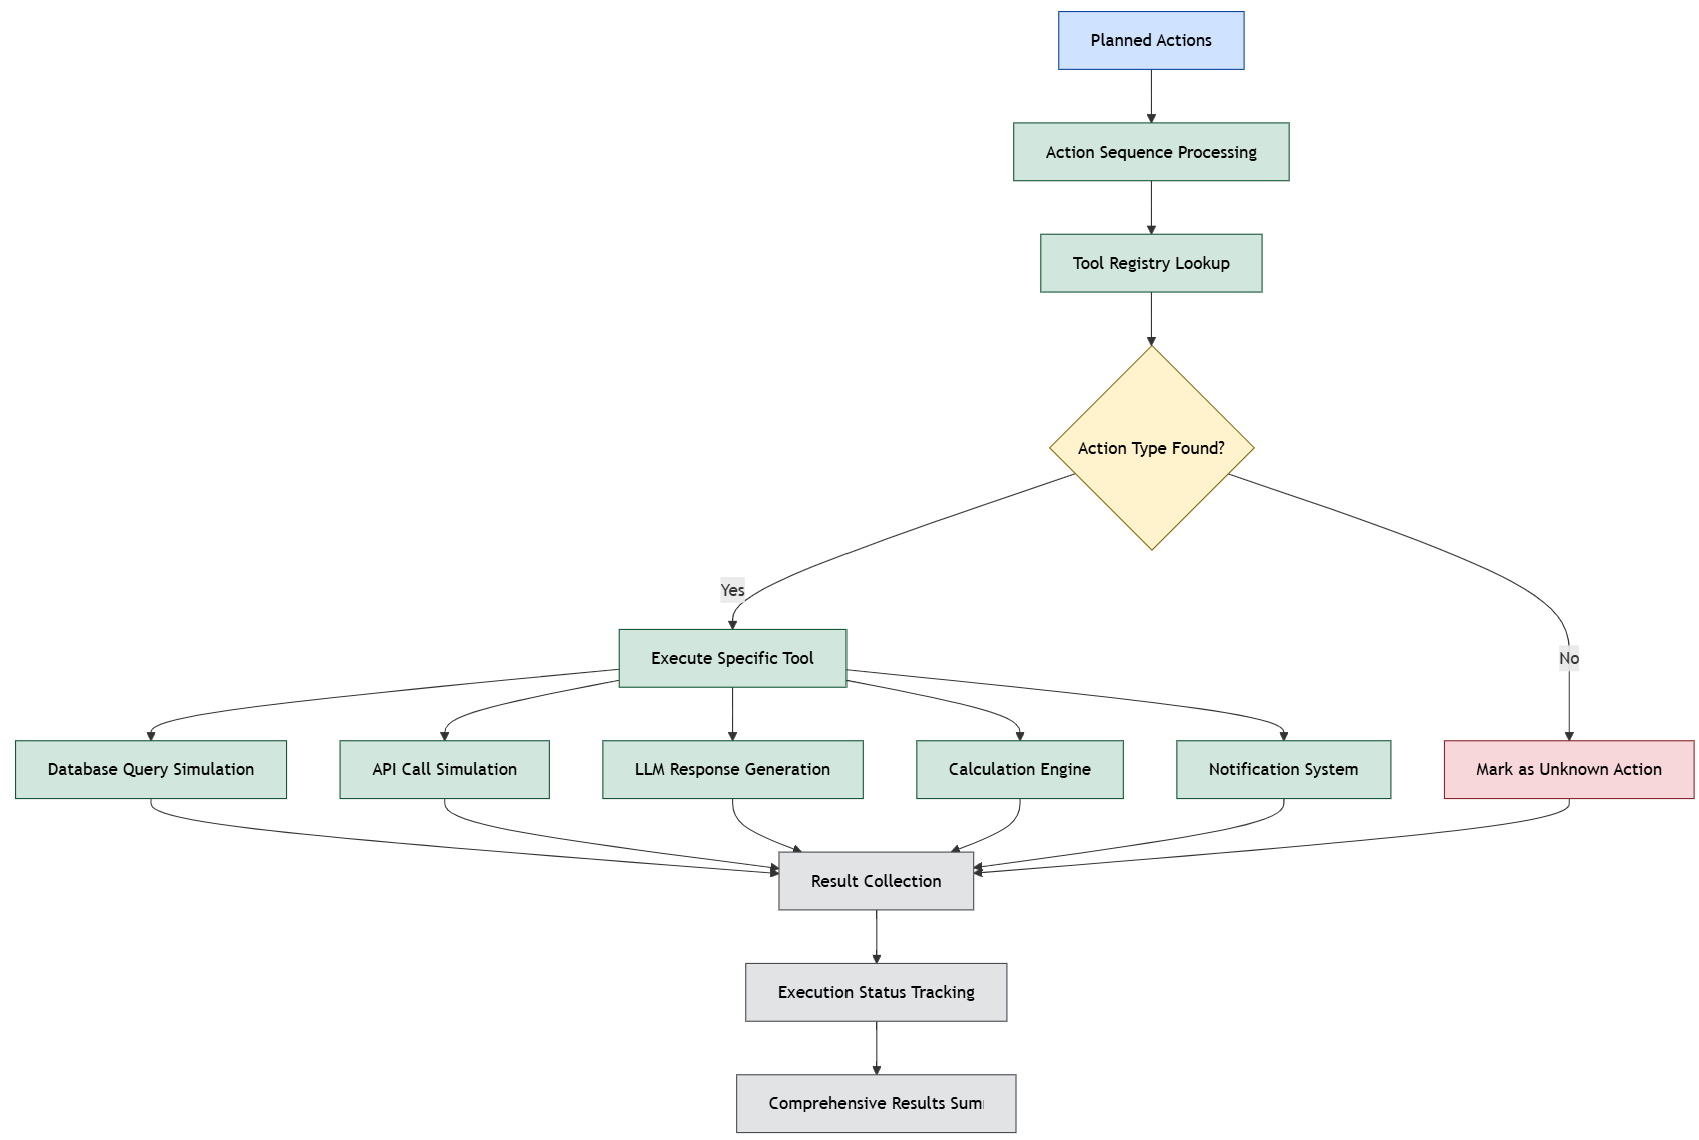

## Desglose del Código Paso a Paso

### Inicialización del Ejecutor de Acciones
- Configuración del Registro de Herramientas: Predefine las herramientas de ejecución disponibles con sus funciones correspondientes
- Arquitectura de Herramientas Modular: Organiza los diferentes tipos de acción en métodos separados y enfocados
- Diseño Extensible: Permite añadir fácilmente nuevos tipos de acción ampliando el registro de herramientas

### Ejecución de la Secuencia de Acciones
- Procesamiento Secuencial: Ejecuta las acciones planificadas en el orden en que se reciben
- Manejo de Errores: Implementa bloques try-catch para evitar que un solo fallo detenga secuencias enteras
- Seguimiento del Estado: Monitorea y reporta el estado de éxito/fracaso de cada intento de acción
- Agregación de Resultados: Recopila las salidas de todas las acciones ejecutadas en un conjunto de resultados completo

### Simulación de Consultas a Bases de Datos
- Sistema de Datos Ficticios: Proporciona respuestas de base de datos simuladas para el desarrollo y las pruebas
- Direccionamiento Basado en Parámetros: Usa los parámetros de la acción para determinar qué datos recuperar
- Formato de Respuesta Realista: Devuelve los datos en formatos estructurados similares a los de los sistemas de base de datos reales
- Simulación de Rendimiento: Incluye una temporización de consulta simulada para un comportamiento realista

### Simulación de Llamadas a API
- Enrutamiento Basado en Endpoints: Dirige las llamadas a API a los endpoints simulados apropiados
- Variación de Respuestas: Proporciona diferentes patrones de respuesta según el tipo de endpoint
- Simulación de Errores: Incluye el manejo de endpoints desconocidos y escenarios de fallo
- Realismo en la Temporización: Simula la latencia de red mediante el reporte del tiempo de respuesta

### Generación de Respuestas en Lenguaje Natural
- Creación de Contenido Impulsada por LLM: Usa modelos de lenguaje para generar respuestas contextualmente apropiadas
- Parametrización del Estilo: Permite controlar el tono y el nivel de detalle de la respuesta
- Integración del Contexto: Incorpora todo el contexto de la conversación en la generación de la respuesta
- Métricas de Respuesta: Rastrea la longitud de la respuesta y el estado de éxito para el monitoreo de la calidad

### Motor de Cálculo
- Implementación de Lógica de Negocio: Realiza cálculos específicos, como montos de reembolso, con reglas de negocio
- Operaciones Impulsadas por Parámetros: Usa los parámetros de la acción para determinar el tipo de cálculo y las entradas
- Lógica Financiera: Implementa cálculos de negocio realistas, como las tarifas de reposición de existencias
- Estructuración de Resultados: Devuelve los resultados de los cálculos en formatos claros y estructurados

### Sistema de Notificaciones
- Soporte Multicanal: Simula notificaciones a través de diferentes métodos de entrega
- Personalización de Mensajes: Permite parametrizar el contenido del mensaje y la selección del destinatario
- Confirmación de Entrega: Proporciona confirmación del estado de las notificaciones enviadas
- Flexibilidad de Métodos: Admite correo electrónico, SMS y otros canales de notificación

### Conexión con la Lección
- Uso de Herramientas en Sistemas de IA: Demuestra la implementación práctica del paradigma de uso de herramientas, donde los LLM orquestan herramientas externas
- Planificación y Ejecución de Acciones: Conecta con los marcos teóricos sobre la separación de la planificación y la ejecución en sistemas inteligentes
- Manejo de Errores en Pipelines: Muestra cómo los sistemas robustos manejan fallos parciales sin un colapso total del sistema
- Simulación frente a Producción: Ilustra la importancia de los sistemas ficticios para el desarrollo antes del despliegue en el mundo real
- Principios de Diseño de API: Demuestra un diseño de interfaz limpio entre los componentes de razonamiento y acción
- Generación de Lenguaje Natural: Se relaciona con las teorías de generación de texto y las métricas de calidad de respuesta en sistemas de diálogo
- Ejecución Secuencial de Acciones: Conecta con la gestión de flujos de trabajo y la secuenciación de acciones en el diálogo orientado a tareas
- Degradación Elegante: Muestra cómo los sistemas mantienen una funcionalidad parcial cuando algunos componentes encuentran problemas

In [ ]:
# action_component.py
class ActionExecutor:
    """
    Executes actions based on reasoning outcomes.
    """

    def __init__(self):
        self.available_tools = {
            "database_query": self.query_database,
            "api_call": self.make_api_call,
            "response_generation": self.generate_response,
            "calculation": self.perform_calculation,
            "notification": self.send_notification
        }

    def execute_actions(self, planned_actions: List[Dict], context: Dict) -> Dict[str, Any]:
        """Execute a sequence of planned actions"""

        results = {}

        for action in planned_actions:
            action_type = action.get("action")
            if action_type in self.available_tools:
                try:
                    result = self.available_tools[action_type](action, context)
                    results[action_type] = result
                    print(f"✅ Executed: {action_type}")
                except Exception as e:
                    results[action_type] = {"status": "error", "error": str(e)}
                    print(f"❌ Failed: {action_type} - {e}")
            else:
                results[action_type] = {"status": "unknown_action"}

        return results

    def query_database(self, action: Dict, context: Dict) -> Dict:
        """Simulate database query"""
        # In real system, this would connect to actual database
        mock_data = {
            "order_1234": {"status": "delivered", "date": "2024-01-15"},
            "user_preferences": {"contact_method": "email", "language": "english"}
        }

        query_target = action.get("parameters", {}).get("target", "")
        return {
            "status": "success",
            "data": mock_data.get(query_target, {}),
            "query_time": "0.05s"
        }

    def make_api_call(self, action: Dict, context: Dict) -> Dict:
        """Simulate API call"""
        endpoint = action.get("parameters", {}).get("endpoint", "")

        # Simulate different API responses
        api_responses = {
            "shipping_status": {"status": "in_transit", "eta": "2024-01-20"},
            "user_profile": {"name": "John Doe", "tier": "premium"},
            "payment_info": {"balance": 150.00, "currency": "USD"}
        }

        return {
            "status": "success",
            "response": api_responses.get(endpoint, {"error": "endpoint_not_found"}),
            "response_time": "0.2s"
        }

    def generate_response(self, action: Dict, context: Dict) -> Dict:
        """Generate natural language response"""

        system_prompt = """
        You are an AI agent responding to a user. Based on the context and action plan,
        generate a helpful, appropriate response.
        """

        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": f"Context: {context}\nAction: {action}"}
            ],
            temperature=0.7
        )

        return {
            "status": "success",
            "response_text": response.choices[0].message.content,
            "response_length": len(response.choices[0].message.content)
        }

    def perform_calculation(self, action: Dict, context: Dict) -> Dict:
        """Perform calculations"""
        calculation_type = action.get("parameters", {}).get("type", "basic")

        if calculation_type == "refund_amount":
            amount = action.get("parameters", {}).get("amount", 0)
            return {"result": amount * 0.9, "currency": "USD"}  # 10% restocking fee

        return {"result": "calculation_completed", "details": action.get("parameters", {})}

    def send_notification(self, action: Dict, context: Dict) -> Dict:
        """Simulate sending notification"""
        return {
            "status": "sent",
            "method": action.get("parameters", {}).get("method", "email"),
            "recipient": action.get("parameters", {}).get("recipient", "user"),
            "message": action.get("parameters", {}).get("message", "Notification sent")
        }

# Demonstrate action execution
def demo_action_executor():
    print("\n=== Action Executor Demo ===")

    executor = ActionExecutor()

    # Sample action plan from reasoning component
    action_plan = [
        {
            "action": "database_query",
            "parameters": {"target": "order_1234"},
            "priority": "high",
            "description": "Check order status"
        },
        {
            "action": "api_call",
            "parameters": {"endpoint": "shipping_status"},
            "priority": "high",
            "description": "Get shipping information"
        },
        {
            "action": "response_generation",
            "parameters": {"style": "empathetic", "detail_level": "high"},
            "priority": "medium",
            "description": "Generate user response"
        }
    ]

    context = {
        "user_query": "Where is my order?",
        "user_tone": "anxious",
        "order_id": "1234"
    }

    results = executor.execute_actions(action_plan, context)

    print("Action Execution Results:")
    for action_type, result in results.items():
        print(f"{action_type}: {result.get('status', 'unknown')}")

demo_action_executor()


=== Action Executor Demo ===
✅ Executed: database_query
✅ Executed: api_call
✅ Executed: response_generation
Action Execution Results:
database_query: success
api_call: success
response_generation: success


## Ejercicio 5: Bucle Completo de Acción/Reflexión

### Concepto: El bucle central del agente, donde percepción → razonamiento → acción → reflexión crea un aprendizaje continuo.

### Descripción Breve
Este código implementa un agente de IA totalmente integrado que combina percepción, razonamiento, acción y reflexión en un ciclo cognitivo completo. Demuestra cómo los sistemas inteligentes pueden procesar las interacciones del usuario de principio a fin, aprender de las experiencias y mantener métricas de rendimiento a lo largo del tiempo. El agente exhibe una mejora continua a través del aprendizaje reflexivo y la integración de la memoria.

### Lógica del Código y Flujo: Visión General de Alto Nivel
El agente completo orquesta un sofisticado bucle cognitivo que comienza percibiendo la entrada del usuario, integra las memorias relevantes, razona sobre la situación, ejecuta las acciones apropiadas y, finalmente, reflexiona sobre la interacción para mejorar el rendimiento futuro. Este pipeline de principio a fin demuestra cómo los sistemas de IA pueden mantener el contexto a lo largo de múltiples interacciones, aprender de las experiencias y autoevaluar su eficacia, a la vez que proporcionan un procesamiento transparente en cada paso.

### Diagrama de Flujo Visual
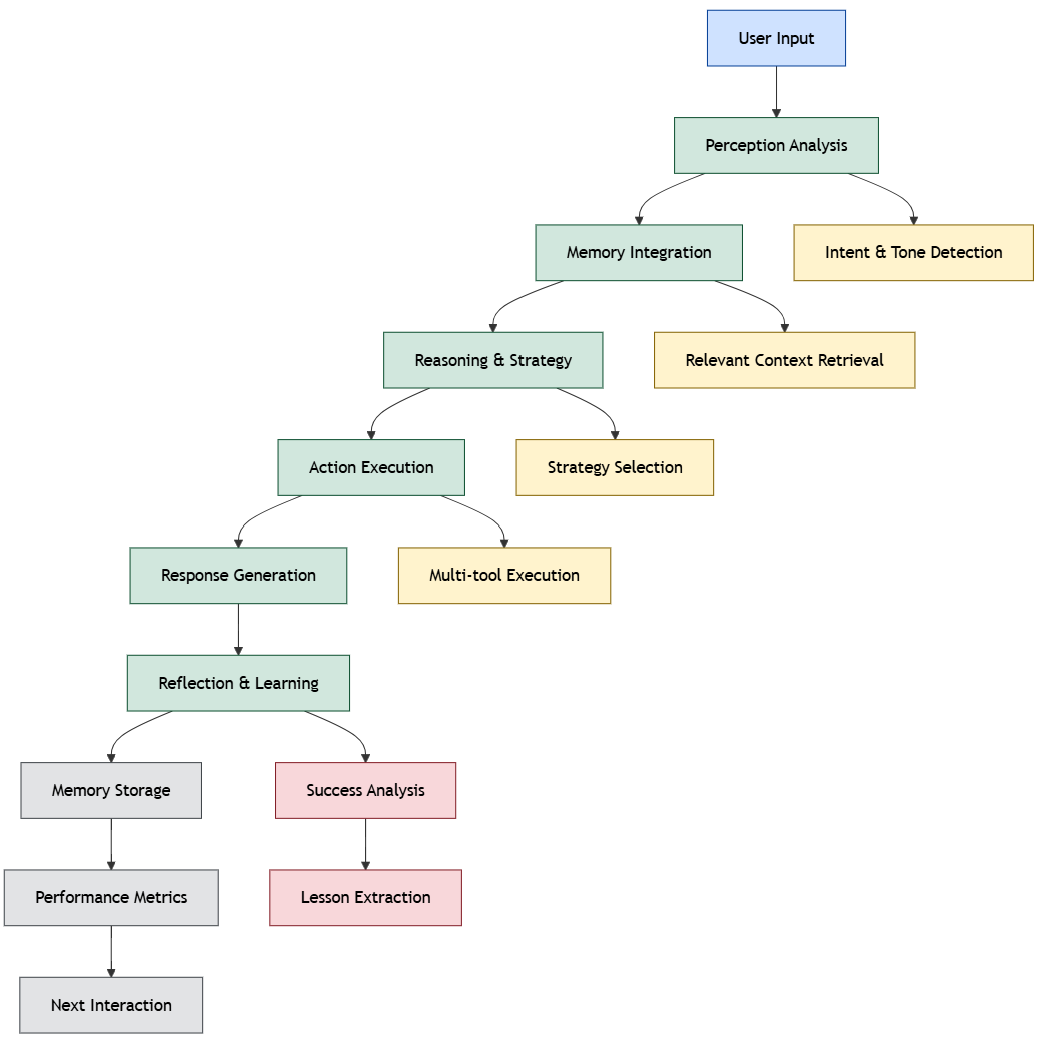

## Desglose del Código Paso a Paso

### Inicialización y Configuración del Agente
- Integración de Componentes: Combina los sistemas de percepción, memoria, razonamiento y acción en una arquitectura unificada
- Seguimiento del Rendimiento: Inicializa métricas completas, incluyendo el recuento de interacciones, las tasas de éxito y las estadísticas de temporización
- Gestión de Identidad: Asigna nombres descriptivos a los agentes para el manejo de tareas especializadas

### Pipeline Completo de Procesamiento de Interacciones
- Medición de la Temporización: Rastrea el tiempo total de procesamiento de cada interacción de principio a fin
- Ejecución Secuencial de Etapas: Avanza a través de las fases de percepción, memoria, razonamiento, acción y reflexión
- Procesamiento Transparente: Proporciona visibilidad en tiempo real de cada etapa de procesamiento con indicadores de estado claros
- Preservación del Contexto: Mantiene y transmite el contexto entre todas las etapas de procesamiento

### Fase de Percepción
- Análisis de la Entrada: Convierte la entrada cruda del usuario en una comprensión estructurada con clasificación de intención y tono
- Retroalimentación en Tiempo Real: Muestra los resultados de la percepción de inmediato para mayor transparencia
- Integración de la Validación: Garantiza que las percepciones analizadas cumplan con los estándares de calidad antes de continuar

### Fase de Integración de la Memoria
- Historial de Conversación: Añade la entrada actual del usuario a la memoria a corto plazo para mantener el contexto
- Recuperación de Contexto Relevante: Busca a través de todos los tipos de memoria información relevante para la situación actual
- Enriquecimiento del Contexto: Mejora el procesamiento actual con patrones y preferencias históricos

### Fase de Razonamiento y Decisión
- Planificación Estratégica: Analiza las percepciones y memorias para determinar el enfoque de respuesta óptimo
- Evaluación de la Confianza: Calcula los niveles de certeza para la estrategia elegida
- Planificación de Acciones: Genera secuencias de acción específicas y ejecutables basadas en decisiones estratégicas

### Fase de Ejecución de Acciones
- Coordinación de Múltiples Herramientas: Ejecuta diversas acciones, incluyendo consultas a bases de datos, llamadas a API y generación de respuestas
- Procesamiento Consciente del Contexto: Proporciona el contexto completo a las herramientas de acción para una ejecución informada
- Extracción de la Respuesta: Captura y da formato a la respuesta principal para su entrega al usuario

### Fase de Reflexión y Aprendizaje
- Análisis Posterior a la Interacción: Evalúa la eficacia de todo el ciclo de interacción
- Puntuación del Éxito: Califica cuantitativamente qué tan bien manejó el agente la situación
- Extracción de Lecciones: Identifica perspectivas y mejoras específicas para futuras interacciones
- Registro de Experiencias: Almacena los patrones exitosos y las lecciones en la memoria episódica

### Sistema de Monitoreo del Rendimiento
- Seguimiento del Tiempo de Respuesta: Calcula y promedia los tiempos de procesamiento a lo largo de todas las interacciones
- Cálculo de la Tasa de Éxito: Monitorea la eficacia de la resolución basándose en las puntuaciones de reflexión
- Métricas de Satisfacción: Deriva estimaciones de la satisfacción del usuario a partir de los patrones de resolución exitosa
- Calibración Continua: Actualiza todas las métricas en tiempo real a medida que ocurren nuevas interacciones

### Reporte del Estado del Agente
- Diagnóstico Integral: Proporciona una visión detallada de las capacidades y el rendimiento del agente
- Estadísticas de Memoria: Reporta la utilización de la memoria a través de los diferentes tipos de almacenamiento
- Visibilidad del Estado de Creencias: Expone las creencias actuales del agente para mayor transparencia y depuración
- Resumen del Rendimiento: Condensa métricas complejas en tasas de éxito comprensibles

### Conexión con la Lección
- Arquitecturas Cognitivas: Implementa una versión práctica de las arquitecturas cognitivas SOAR y ACT-R discutidas en las clases teóricas
- Aprendizaje por Refuerzo: Demuestra cómo la reflexión y la extracción de lecciones permiten un aprendizaje basado en la experiencia, similar a las señales de recompensa en el aprendizaje por refuerzo
- Mejora Continua: Muestra cómo los sistemas de IA pueden mejorar iterativamente mediante la autoevaluación y la memoria de éxitos/fracasos pasados
- Gestión del Diálogo de Múltiples Turnos: Ilustra técnicas para mantener el contexto y la coherencia a lo largo de conversaciones extensas
- Evaluación del Rendimiento en IA: Conecta con los marcos teóricos para evaluar sistemas de IA conversacional mediante métricas cuantitativas
- Sistemas de IA Transparentes: Demuestra la importancia de las etapas de procesamiento explicables para la confianza y la depuración
- Redes Neuronales Aumentadas por Memoria: Muestra la implementación práctica de sistemas de memoria externa para superar las limitaciones de la ventana de contexto
- Colaboración Humano-IA: Resalta cómo las métricas de rendimiento ayudan a comprender y optimizar la asistencia de la IA en escenarios del mundo real

In [ ]:
# action_reflection_loop.py
class CompleteAgent:
    """
    Implements the full perception-reasoning-action-reflection loop.
    """

    def __init__(self, name: str = "CustomerServiceAgent"):
        self.name = name
        self.perception = PerceptionModule()
        self.memory = MemorySystem()
        self.reasoning = ReasoningEngine(self.memory)
        self.action = ActionExecutor()
        self.performance_metrics = {
            "total_interactions": 0,
            "successful_resolutions": 0,
            "average_response_time": 0,
            "user_satisfaction_score": 0.0
        }

    def process_interaction(self, user_input: str, current_goal: str = None) -> Dict[str, Any]:
        """Execute one complete interaction cycle"""

        start_time = datetime.now()
        self.performance_metrics["total_interactions"] += 1

        print(f"\n🔄 {self.name} Processing: '{user_input}'")
        print("-" * 50)

        # Step 1: Perception
        print("1. 📝 PERCEPTION")
        perception_result = self.perception.parse_input(user_input)
        print(f"   Intent: {perception_result['intent']}")
        print(f"   Tone: {perception_result['tone']}")

        # Step 2: Memory Integration
        self.memory.add_to_short_term("user", user_input)
        relevant_memories = self.memory.retrieve_relevant_memory(user_input)

        # Step 3: Reasoning
        print("2. 🤔 REASONING")
        reasoning_result = self.reasoning.process_situation(perception_result, current_goal)
        print(f"   Strategy: {reasoning_result['strategy']}")
        print(f"   Confidence: {reasoning_result['confidence']:.2f}")

        # Step 4: Action
        print("3. 🎯 ACTION")
        action_results = self.action.execute_actions(reasoning_result['next_actions'], {
            "perception": perception_result,
            "reasoning": reasoning_result,
            "memories": relevant_memories
        })

        # Extract response text
        response_text = ""
        if "response_generation" in action_results:
            response_text = action_results["response_generation"].get("response_text", "No response generated")

        # Step 5: Reflection
        print("4. 🔄 REFLECTION")
        reflection_insights = self.reflect_on_interaction(
            user_input, response_text, perception_result, reasoning_result, action_results
        )

        # Update memory with this experience
        self.memory.add_to_short_term("assistant", response_text)
        self.memory.record_episode(
            f"Handled {perception_result['intent']} request",
            f"Response: {response_text[:100]}...",
            reflection_insights.get("lessons_learned", [])
        )

        # Calculate performance metrics
        interaction_time = (datetime.now() - start_time).total_seconds()
        self.update_performance_metrics(interaction_time, reflection_insights.get("success_score", 0.5))

        return {
            "response": response_text,
            "perception": perception_result,
            "reasoning": reasoning_result,
            "actions": action_results,
            "reflection": reflection_insights,
            "performance": self.performance_metrics.copy()
        }

    def reflect_on_interaction(self, user_input: str, response: str,
                             perception: Dict, reasoning: Dict, actions: Dict) -> Dict[str, Any]:
        """Reflect on the interaction to improve future performance"""

        system_prompt = """
        You are an AI agent reflecting on your recent interaction. Analyze:
        1. How well you understood the user's needs
        2. Whether your response was effective
        3. What you could have done better
        4. Key lessons learned

        Return JSON with:
        - success_score: 0-1 rating of interaction success
        - effectiveness_analysis: brief analysis of what worked/didn't
        - improvements_needed: specific areas for improvement
        - lessons_learned: list of key takeaways
        """

        context = f"""
        User Input: {user_input}
        My Response: {response}
        My Perception: {perception}
        My Reasoning: {reasoning.get('reasoning_trace', [])}
        Actions Taken: {list(actions.keys())}
        """

        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": context}
            ],
            temperature=0.3
        )

        try:
            return json.loads(response.choices[0].message.content)
        except:
            return {
                "success_score": 0.7,
                "effectiveness_analysis": "Standard response generated",
                "improvements_needed": ["Better context understanding"],
                "lessons_learned": ["Need more specific user intent analysis"]
            }

    def update_performance_metrics(self, response_time: float, success_score: float):
        """Update ongoing performance metrics"""
        total = self.performance_metrics["total_interactions"]
        current_avg = self.performance_metrics["average_response_time"]

        # Update average response time
        self.performance_metrics["average_response_time"] = (
            (current_avg * (total - 1) + response_time) / total
        )

        # Update success rate
        if success_score > 0.8:
            self.performance_metrics["successful_resolutions"] += 1

        # Update satisfaction score (simplified)
        self.performance_metrics["user_satisfaction_score"] = (
            self.performance_metrics["successful_resolutions"] / total
        )

    def get_agent_status(self) -> Dict[str, Any]:
        """Get current agent status and capabilities"""
        return {
            "name": self.name,
            "interactions_processed": self.performance_metrics["total_interactions"],
            "success_rate": f"{(self.performance_metrics['successful_resolutions'] / self.performance_metrics['total_interactions']) * 100:.1f}%",
            "average_response_time": f"{self.performance_metrics['average_response_time']:.2f}s",
            "memory_stats": {
                "short_term": len(self.memory.short_term_memory),
                "long_term": sum(len(category) for category in self.memory.long_term_memory.values()),
                "episodic": len(self.memory.episodic_memory)
            },
            "current_beliefs": self.reasoning.current_beliefs
        }

# Demonstrate complete agent loop
def demo_complete_agent():
    print("=== Complete Agent: Action/Reflection Loop ===")

    agent = CompleteAgent("CustomerServicePro")

    # Simulate a conversation with the agent
    conversation = [
        "Hello, I need help with my recent order",
        "The order number is 1234 and it hasn't arrived yet",
        "Can you give me an estimated delivery date?",
        "Thanks, that's helpful. Also, I want to update my contact preferences to email only"
    ]

    for i, user_input in enumerate(conversation, 1):
        print(f"\n{'#' * 20} Interaction {i} {'#' * 20}")
        result = agent.process_interaction(user_input, "provide_customer_support")

        print(f"\n🤖 Agent Response:")
        print(f"{result['response']}")

        print(f"\n📊 Reflection Insights:")
        print(f"Success Score: {result['reflection'].get('success_score', 0):.2f}")
        print(f"Lessons: {result['reflection'].get('lessons_learned', [])}")

    # Show final agent status
    print(f"\n{'#' * 50}")
    print("FINAL AGENT STATUS:")
    status = agent.get_agent_status()
    for key, value in status.items():
        print(f"{key}: {value}")

demo_complete_agent()

=== Complete Agent: Action/Reflection Loop ===

#################### Interaction 1 ####################

🔄 CustomerServicePro Processing: 'Hello, I need help with my recent order'
--------------------------------------------------
1. 📝 PERCEPTION
   Intent: request
   Tone: neutral
2. 🤔 REASONING
   Strategy: information_gathering
   Confidence: 0.85
3. 🎯 ACTION
4. 🔄 REFLECTION

🤖 Agent Response:


📊 Reflection Insights:
Success Score: 0.70
Lessons: ['Need more specific user intent analysis']

#################### Interaction 2 ####################

🔄 CustomerServicePro Processing: 'The order number is 1234 and it hasn't arrived yet'
--------------------------------------------------
1. 📝 PERCEPTION
   Intent: complaint
   Tone: negative
2. 🤔 REASONING
   Strategy: problem_solving
   Confidence: 0.65
3. 🎯 ACTION
4. 🔄 REFLECTION

🤖 Agent Response:


📊 Reflection Insights:
Success Score: 0.70
Lessons: ['Need more specific user intent analysis']

#################### Interaction 3 #######

## Aprendizaje Clave: El bucle de acción/reflexión permite el aprendizaje y la mejora continuos.

### 🎓 Guía Didáctica

### Conceptos Centrales Demostrados
- Percepción: Transformar la entrada cruda en una comprensión estructurada
- Memoria: Mantener el contexto a través de diferentes horizontes temporales
- Razonamiento: Tomar decisiones basadas en la información disponible
- Acción: Provocar cambios en el entorno
- Reflexión: Aprender de las experiencias para mejorar el rendimiento futuro

### Actividades para el Aula
- Análisis de Componentes: Pedir a los estudiantes que identifiquen qué componente manejaría escenarios específicos
- Ejercicio de Depuración: Proporcionar código de agente defectuoso y pedir a los estudiantes que arreglen componentes específicos
- Reto de Diseño: Diseñar nuevos componentes para dominios especializados (médico, legal, etc.)
- Optimización del Rendimiento: Desafiar a los estudiantes a mejorar la eficiencia del agente

### Preguntas de Discusión
- "¿Cómo afecta la calidad de la percepción al razonamiento y las acciones posteriores?"
- "¿Cuáles son los compromisos entre las diferentes estrategias de almacenamiento de memoria?"
- "¿Cómo se puede hacer que la reflexión sea más eficaz para el aprendizaje a largo plazo?"
- "¿Qué consideraciones éticas surgen de los agentes que aprenden de las interacciones del usuario?"

### Métricas de Evaluación
- Comprensión de Componentes: ¿Pueden los estudiantes explicar el rol de cada componente?
- Habilidades de Integración: ¿Pueden los estudiantes conectar los componentes en la secuencia correcta?
- Capacidad de Depuración: ¿Pueden los estudiantes identificar qué componente fallaría en escenarios dados?
- Pensamiento de Diseño: ¿Pueden los estudiantes proponer mejoras a la arquitectura del agente?

Estos ejercicios proporcionan una base integral para comprender los componentes fundamentales de los agentes de IA y cómo trabajan juntos para crear un comportamiento inteligente.